# Speech Emotion Recognition on CREMA-D — Classical vs Quantum

End-to-end training and evaluation notebook for classical and hybrid quantum-classical models on the [CREMA-D](https://github.com/CheyneyComputerScience/CREMA-D) speech emotion corpus.

## Supported architectures

| Key | Type | Backbone |
|---|---|---|
| `emb_resnet18` | Transfer learning | ResNet-18 ImageNet embeddings (frozen) |
| `emb_vgg16` | Transfer learning | VGG-16 ImageNet embeddings (frozen) |
| `emb_panns_cnn14` | Transfer learning | PANNs CNN14 audio embeddings (frozen) |
| `cnn_mfcc` | CNN from scratch | ResNet-18 (1-channel) on MFCC spectrograms |
| `cnn_specs` | CNN from scratch | ResNet-18 (3-channel) on spectrogram PNGs |
| `custom_cnn` | CNN from scratch | Lightweight 4-layer custom CNN |
| `resnet18` | End-to-end | Full ResNet-18, pretrained ImageNet |
| `vgg16` | End-to-end | Full VGG-16, pretrained ImageNet |

## Training modes

- **Single-stage**: backbone frozen, only the classification head is trained.
- **Two-stage fine-tuning**: pre-trains the head first, then unfreezes and fine-tunes end-to-end.

## Classification heads

- **Classical**: dense MLP `nn.Linear`.
- **Quantum (USE_QUANTUM=True)**: Variational Quantum Circuit (VQC) via PennyLane — `AngleEmbedding + BasicEntanglerLayers`, followed by a final `nn.Linear` projection to class logits.

In [2]:
# Install Pennylane for quantum simulation and torchinfo for model summary (Colab)
import subprocess, sys

packages = [
    "pennylane",
    "torchinfo",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

print("Dependencies ready.")

Dependencies ready.


## 1. Environment Setup

Mounts Google Drive for persistent storage, clones the repository to the Colab runtime, and installs PennyLane and `torchinfo`.

> **Why Drive?** Training checkpoints, model weights, and exported quantum artifacts are saved directly to Drive so they persist between sessions.

In [3]:
# Colab setup: mount Drive, clone repo, checkout fine-tunning branch
import os, sys, subprocess
from pathlib import Path

REPO_URL = 'https://github.com/lburdman/qnn-transfer-learning.git'
REPO_PATH = Path('/content/qnn-transfer-learning')
BRANCH = 'main'

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    if not REPO_PATH.exists():
        subprocess.run(['git', 'clone', REPO_URL, str(REPO_PATH)], check=True)
    os.chdir(REPO_PATH)
    subprocess.run(['git', 'fetch'], check=True)
    subprocess.run(['git', 'checkout', BRANCH], check=True)
    subprocess.run(['git', 'pull', 'origin', BRANCH], check=True)
else:
    os.chdir(Path('.'))

sys.path.append(str(Path.cwd() / 'src'))
print('Working dir:', Path.cwd())
print('Python path updated with src/')


Mounted at /content/drive
Working dir: /content/qnn-transfer-learning
Python path updated with src/


In [4]:
import json, time, random
from pathlib import Path
from dataclasses import dataclass
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.utils import configure_run, print_model_summary
from src.dataset import create_dataloaders_all
from src.model_builder import build_model
from src.training import (
    train_with_history,
    train_model,
    evaluate_model,
    pretrain_backbone_and_embedding,
    finetune_head_only,
    summarize_experiments,
    freeze_module_params,
    FineTuneConfig,
)
from src.quantum_circuit import draw_qnode_circuit_example, analyze_trained_quantum_head

print('Imports ready')


Imports ready


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


## 2. Experiment Configuration

All tunable parameters live in this single cell. Edit here before running any downstream cell.

| Variable | Description |
|---|---|
| `BASE_MODEL` | Architecture key (see table in the title cell) |
| `FINE_TUNING` | `True` = two-stage fine-tune; `False` = single-stage |
| `USE_QUANTUM` | `True` = VQC head (PennyLane); `False` = classical MLP |
| `N_QUBITS` | Number of qubits / bottleneck dimension (only relevant when `USE_QUANTUM=True`) |
| `Q_DEPTH` | Number of `BasicEntanglerLayers` repetitions |
| `SELECTED_CLASSES` | List of emotion labels to include, or `None` for all six |
| `BATCH_SIZE` | DataLoader batch size — reduce if running out of GPU memory |
| `EPOCHS_PRETRAIN` | Stage-1 epochs (only used when `FINE_TUNING=True`) |
| `EPOCHS_FINETUNE` | Stage-2 / single-stage epoch count |
| `LR_PRETRAIN` / `LR_FINETUNE` | Learning rates for each stage |
| `RNG_SEED` | Global random seed for reproducibility |

In [6]:
# ============================================================
# EXPERIMENT CONFIGURATION
# Edit any of the variables below to change the experiment.
# No widget dependencies -- plain Python only.
# ============================================================

# --- Base model / feature extractor ---
# Determines how audio is encoded before the classification head.
#
# Precomputed-embedding models (frozen backbone, head trains on saved vectors):
#   'emb_resnet18'     -- ResNet-18 ImageNet embeddings
#   'emb_vgg16'        -- VGG-16 ImageNet embeddings
#   'emb_panns_cnn14'  -- PANNs CNN14 audio embeddings
#
# CNN pipelines trained from audio representations (no pre-saved embeddings):
#   'cnn_mfcc'   -- ResNet-18 (1-channel, weights=None) on MFCC images
#   'cnn_specs'  -- ResNet-18 (3-channel, weights=None) on spectrogram PNGs
#   'custom_cnn' -- Lightweight custom 4-layer CNN backbone (1-channel)
#
# Direct end-to-end backbone models:
#   'resnet18' -- Full ResNet-18 with pretrained ImageNet weights
#   'vgg16'    -- Full VGG-16 with pretrained ImageNet weights
BASE_MODEL = 'emb_resnet18'

# --- Training mode ---
# True  = two-stage fine-tuning (pretrain backbone, then fine-tune end-to-end)
# False = single-stage training (train head only, backbone frozen throughout)
FINE_TUNING = False

# --- Classification head ---
# True  = Variational Quantum Circuit (VQC) head via PennyLane
# False = Classical dense MLP head
USE_QUANTUM = True

# --- Quantum hyperparameters (only used when USE_QUANTUM=True) ---
# N_QUBITS: number of qubits / bottleneck dimension (2-16 recommended)
# Q_DEPTH:  number of BasicEntanglerLayers repetitions (1-6 recommended)
N_QUBITS = 2
Q_DEPTH  = 3

# --- Emotion classes (None = use all available classes) ---
SELECTED_CLASSES = ['ANG', 'SAD']  # e.g. ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD'] or None

# --- Dataloader ---
BATCH_SIZE = 8  # Reduce if running out of GPU memory

# --- Training epochs ---
EPOCHS_PRETRAIN = 4    # Stage-1 epochs (only used when FINE_TUNING=True)
EPOCHS_FINETUNE = 20   # Stage-2 (fine-tune) or single-stage epoch count

# --- Learning rates ---
LR_PRETRAIN = 1e-3     # Stage-1 LR (only used when FINE_TUNING=True)
LR_FINETUNE = 4e-4     # Stage-2 / single-stage LR

# --- Reproducibility ---
RNG_SEED = 42

# Verification bundle: how many samples to export (balanced across classes)
N_VERIFICATION_SAMPLES = 200

print('Configuration:')
print(f'  BASE_MODEL      = {BASE_MODEL}')
print(f'  FINE_TUNING     = {FINE_TUNING}')
print(f'  USE_QUANTUM     = {USE_QUANTUM}')
if USE_QUANTUM:
    print(f'  N_QUBITS/Q_DEPTH= {N_QUBITS} / {Q_DEPTH}')
print(f'  SELECTED_CLASSES= {SELECTED_CLASSES}')
print(f'  BATCH_SIZE      = {BATCH_SIZE}')


Configuration:
  BASE_MODEL      = emb_resnet18
  FINE_TUNING     = False
  USE_QUANTUM     = True
  N_QUBITS/Q_DEPTH= 2 / 3
  SELECTED_CLASSES= ['ANG', 'SAD']
  BATCH_SIZE      = 8


In [7]:
import random
import sys
from pathlib import Path

# --- Data root (auto-detected for Colab vs local) ---
DATA_ROOT = '/content/drive/MyDrive/CREMAD' if 'google.colab' in sys.modules else str(Path.cwd() / 'CREMAD')

# --- Epoch and LR aliases ---
EPOCHS = EPOCHS_FINETUNE
LEARNING_RATE = LR_FINETUNE

# --- Seeding ---
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RNG_SEED)

# --- Build experiment config ---
if FINE_TUNING:
    config = configure_run(
        base_model=BASE_MODEL,
        quantum=USE_QUANTUM,
        classical_model='512_nq_2',
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        selected_classes=SELECTED_CLASSES,
        batch_size=BATCH_SIZE,
        num_epochs=EPOCHS_FINETUNE,
        learning_rate=LR_FINETUNE,
        data_root=DATA_ROOT,
    )
    config['num_epochs_pretrain'] = EPOCHS_PRETRAIN
    config['learning_rate_pretrain'] = LR_PRETRAIN
else:
    config = configure_run(
        base_model=BASE_MODEL,
        quantum=USE_QUANTUM,
        classical_model='512_nq_2',
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        selected_classes=SELECTED_CLASSES,
        batch_size=BATCH_SIZE,
        num_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        data_root=DATA_ROOT,
    )
print(json.dumps(config, indent=2))


{
  "run_id": "03-18_20-43-29",
  "base_model": "emb_resnet18",
  "quantum": true,
  "classical_model": "512_nq_2",
  "n_qubits": 2,
  "q_depth": 3,
  "selected_classes": [
    "ANG",
    "SAD"
  ],
  "batch_size": 8,
  "num_epochs": 20,
  "learning_rate": 0.0004,
  "data_root": "/content/drive/MyDrive/CREMAD",
  "specs_dir": "/content/drive/MyDrive/CREMAD/Spectrograms",
  "embedding_dir": "/content/drive/MyDrive/CREMAD/Embeddings",
  "mfcc_dir": "/content/drive/MyDrive/CREMAD/MFCC",
  "rng_seed": 42,
  "save_root": "/content/drive/MyDrive/CREMAD/Models",
  "model_dir": "/content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-18_20-43-29"
}


## 3. Data Ingestion

`create_dataloaders_all` parses the CREMA-D corpus (or pre-extracted feature datasets, depending on `BASE_MODEL`) and returns PyTorch `DataLoader` objects for `train`, `val`, and `test` splits.

What happens here:
- Audio files are converted to spectrograms or MFCC images (if using CNN pipelines), or embeddings are loaded directly from disk (if using `emb_*` models).
- Class filtering is applied based on `SELECTED_CLASSES`.
- Splits are stratified to maintain class balance across train/val/test.

> The data split configuration has the most impact on final generalization. Check the class distribution printout before training.

In [8]:
dataloaders, dataset_sizes, class_names, counts_per_class = create_dataloaders_all(config, shuffle=True, num_workers=0)
print('Splits sizes:', dataset_sizes)
print('Classes:', class_names)
phase = 'train' if 'train' in dataloaders else list(dataloaders.keys())[0]
sample_x, sample_y = next(iter(dataloaders[phase]))
print('Sample batch shape:', sample_x.shape)
print('Label shape:', sample_y.shape)
print('Counts per class (train):', counts_per_class.get('train', {}))


Splits sizes: {'train': 1779, 'val': 481, 'test': 508}
Classes: ['ANG', 'SAD']
Sample batch shape: torch.Size([8, 512])
Label shape: torch.Size([8])
Counts per class (train): {'ANG': 890, 'SAD': 889}


ASCII circuit diagram (templates):
0: ──H──RY(0.86)──╭●──RY(0.63)─╭●──RY(0.21)─╭●──RY(0.09)─┤  <Z>
1: ──H──RY(-1.45)─╰X──RY(0.83)─╰X──RY(0.46)─╰X──RY(0.87)─┤  <Z>


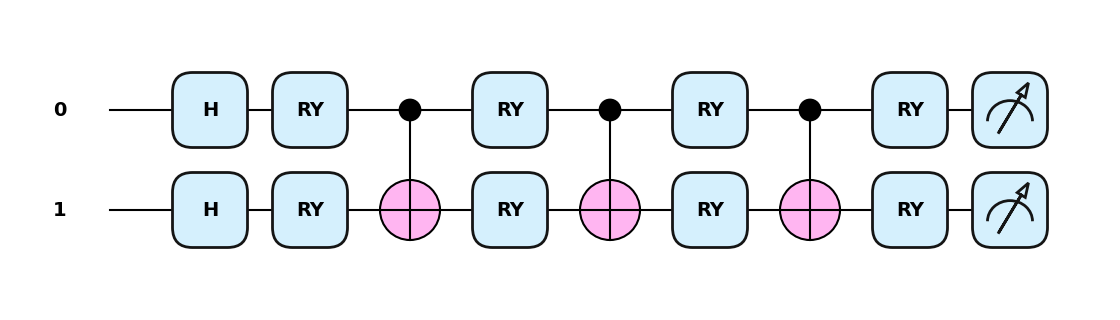


ASCII decomposed circuit (basic gates):
0: ──H──RY(0.86)──╭●──RY(0.63)─╭●──RY(0.21)─╭●──RY(0.09)─┤  <Z>
1: ──H──RY(-1.45)─╰X──RY(0.83)─╰X──RY(0.46)─╰X──RY(0.87)─┤  <Z>


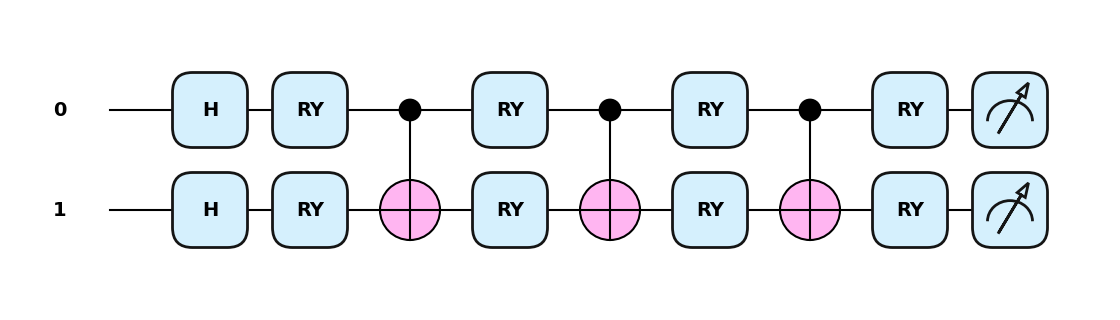

In [10]:
if USE_QUANTUM:
    try:
        draw_qnode_circuit_example(n_qubits=N_QUBITS, q_depth=Q_DEPTH, max_layers=None, seed=0)
    except Exception as exc:
        print('Quantum preview skipped:', exc)
else:
    print('Quantum preview skipped (USE_QUANTUM=False)')


In [11]:
# Preview model (if buildable) before training
try:
    preview_model = build_model(config, class_names, dataloaders, device)
    print_model_summary(preview_model)
except Exception as exc:
    print('Preview model summary skipped:', exc)


Sequential(
  (0): Linear(in_features=512, out_features=2, bias=True)
  (1): ReLU()
  (2): <Quantum Torch Layer: func=circuit>
  (3): Linear(in_features=2, out_features=2, bias=True)
)
Total params: 1,038
Trainable params: 1,038
Classical params: 1,032
Quantum params: 6


## 4. Training

Depending on `FINE_TUNING`, one of two training protocols is executed:

### Single-stage (`FINE_TUNING = False`)
The backbone is frozen. Only the classification head is trained for `EPOCHS_FINETUNE` epochs at `LR_FINETUNE`.

### Two-stage fine-tuning (`FINE_TUNING = True`)
1. **Stage 1 — Head pre-training**: backbone frozen, head trained for `EPOCHS_PRETRAIN` epochs at `LR_PRETRAIN`.
2. **Stage 2 — End-to-end fine-tuning**: entire network unfrozen and trained for `EPOCHS_FINETUNE` epochs at `LR_FINETUNE`.

`best_model` is set to the checkpoint with the highest validation accuracy across all epochs. Training history is saved for plotting.

In [12]:
history_stage1 = {}
history_stage2 = {}
final_acc = None
best_model = None

if FINE_TUNING and BASE_MODEL == 'emb_resnet18':
    ft_cfg = FineTuneConfig(
        representation=BASE_MODEL,
        n_qubits=N_QUBITS,
        q_depth=Q_DEPTH,
        pretrain_epochs=EPOCHS_PRETRAIN,
        finetune_epochs=EPOCHS_FINETUNE,
        learning_rate_pretrain=LR_PRETRAIN,
        learning_rate_finetune_classical=LR_FINETUNE,
        learning_rate_finetune_quantum=LR_FINETUNE,
        backbone_dir=str(Path(DATA_ROOT) / 'Models' / 'backbone'),
        batch_size=BATCH_SIZE,
        device_override=None,
    )
    stage1_model, history_stage1, checkpoint = pretrain_backbone_and_embedding(
        dataloaders, dataset_sizes, class_names, ft_cfg, representation_tag=BASE_MODEL
    )
    head_type = 'quantum' if USE_QUANTUM else 'classical'
    best_model, history_stage2, final_acc = finetune_head_only(
        checkpoint, dataloaders, dataset_sizes, class_names, ft_cfg, head_type=head_type,
        representation_tag=BASE_MODEL
    )
else:
    best_model = build_model(config, class_names, dataloaders, device=device)
    best_model, history_stage1 = train_model(
        best_model, dataloaders, dataset_sizes, device, config['num_epochs'], config['learning_rate'], config['model_dir']
    )
    final_acc = history_stage1.get('test_acc', [0])[-1] if history_stage1.get('test_acc') else 0
print('Final test acc estimate:', f'{final_acc:.4f}')


Epoch 1/20
------------------------------


train 1/20:   0%|          | 0/223 [00:00<?, ?it/s]

train Loss: 0.5764  Acc: 0.8212  F1: 0.8209


test 1/20:   0%|          | 0/64 [00:00<?, ?it/s]

test Loss: 0.5096  Acc: 0.8976  F1: 0.8973

Epoch 2/20
------------------------------


...

test Loss: 0.2185  Acc: 0.9429  F1: 0.9429

Epoch 20/20
------------------------------


train 20/20:   0%|          | 0/223 [00:00<?, ?it/s]

train Loss: 0.2145  Acc: 0.9466  F1: 0.9466


test 20/20:   0%|          | 0/64 [00:00<?, ?it/s]

test Loss: 0.2166  Acc: 0.9409  F1: 0.9409

History saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-18_20-43-29/history.json
Metrics saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-18_20-43-29/metrics.json
Final test acc estimate: 0.9409


## 5. Architectural Introspection

Prints a `torchinfo` model summary showing layer shapes, frozen vs. trainable parameter counts, and total FLOPs. Use this to verify:

- The backbone is frozen (zero trainable params in backbone layers) during stage-1.
- The quantum layer is present and its parameter count matches `N_QUBITS × Q_DEPTH` (for `BasicEntanglerLayers`).

In [13]:
# Model summary
print_model_summary(best_model)


Sequential(
  (0): Linear(in_features=512, out_features=2, bias=True)
  (1): ReLU()
  (2): <Quantum Torch Layer: func=circuit>
  (3): Linear(in_features=2, out_features=2, bias=True)
)
Total params: 1,038
Trainable params: 1,038
Classical params: 1,032
Quantum params: 6


In [14]:
# Load utilities
from src.quantum_weights import (
   extract_quantum_weights,
   summarize_quantum_weights,
   find_classical_to_quantum_mapper
)

# Confirm output summaries natively support Colab print buffers cleanly
print("Weights Summary:", summarize_quantum_weights(best_model))
print("Classical projection:", find_classical_to_quantum_mapper(best_model))


Weights Summary: {'weights': {'name': 'weights', 'shape': (3, 2), 'dtype': 'torch.float32', 'min': 1.2158055305480957, 'max': 6.303520202636719, 'mean': 3.3877274990081787, 'std': 2.321847438812256, 'first_few_values': [6.262232780456543, 2.3613998889923096, 1.2158055305480957, 1.3635916709899902, 6.303520202636719]}}
Classical projection: Linear(in_features=512, out_features=2, bias=True)


Saved plot to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-18_20-43-29/stage1_metrics.png


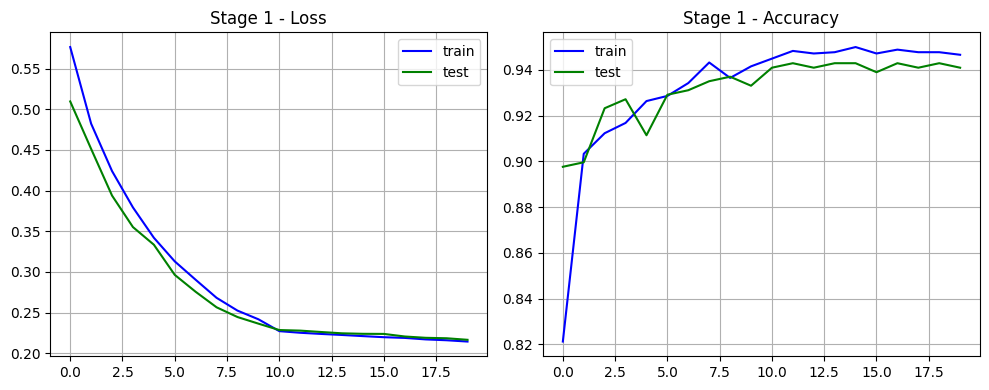

In [15]:
def plot_history(history, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    for phase, color in [('train','blue'), ('test','green')]:
        if f'{phase}_loss' in history:
            axes[0].plot(history[f'{phase}_loss'], label=f'{phase}', color=color)
        if f'{phase}_acc' in history:
            axes[1].plot(history[f'{phase}_acc'], label=f'{phase}', color=color)
    axes[0].set_title(f'{title} - Loss'); axes[1].set_title(f'{title} - Accuracy')
    for ax in axes:
        ax.legend(); ax.grid(True)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print('Saved plot to', save_path)
    plt.show()

plot_history(history_stage1, 'Stage 1', save_path=Path(config['model_dir'])/'stage1_metrics.png')
if history_stage2:
    plot_history(history_stage2, 'Stage 2', save_path=Path(config['model_dir'])/'stage2_metrics.png')


## 6. Evaluation

Runs the best checkpoint over the `val` and `test` splits and reports:

- **Accuracy** — fraction of correctly classified samples.
- **Weighted F1-score** — accounts for class imbalance; the primary metric for CREMA-D.
- **Confusion matrix** — reveals per-class prediction biases (e.g. confusing Anger with Disgust).

Results are saved to `metrics.json` inside the model directory.

In [16]:
metrics = {}
if 'val' in dataloaders:
    metrics['val'] = evaluate_model(best_model, dataloaders['val'], class_names, device, config['model_dir'], split_name='val')
if 'test' in dataloaders:
    metrics['test'] = evaluate_model(best_model, dataloaders['test'], class_names, device, config['model_dir'], split_name='test')
for split, vals in metrics.items():
    acc = vals.get('accuracy', 0)
    f1 = vals.get('f1_weighted', 0)
    print(f'{split.upper()} accuracy: {acc:.4f}, F1: {f1:.4f}')
print(metrics)


Evaluating (val):   0%|          | 0/61 [00:00<?, ?it/s]

VAL metrics saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-18_20-43-29/val_metrics.json
VAL Accuracy: 0.9397 | F1: 0.9397
Confusion matrix saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-18_20-43-29/confusion_matrix_val.png


Evaluating (test):   0%|          | 0/64 [00:00<?, ?it/s]

TEST metrics saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-18_20-43-29/test_metrics.json
TEST Accuracy: 0.9429 | F1: 0.9429
Confusion matrix saved to /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-18_20-43-29/confusion_matrix_test.png
VAL accuracy: 0.9397, F1: 0.9397
TEST accuracy: 0.9429, F1: 0.9429
{'val': {'accuracy': 0.9397089397089398, 'precision_weighted': 0.9398861355631395, 'recall_weighted': 0.9397089397089398, 'f1_weighted': 0.9396959044240687}, 'test': {'accuracy': 0.9429133858267716, 'precision_weighted': 0.9429751809881098, 'recall_weighted': 0.9429133858267716, 'f1_weighted': 0.9429113948576854}}


## 7. Quantum Inspection *(hybrid models only)*

When `USE_QUANTUM=True`, this section uses `src.quantum_weights` utilities to non-destructively inspect the trained quantum head without modifying any parameters.

| Utility | What it shows |
|---|---|
| `summarize_quantum_weights` | Shape, min, max, mean, std of all trainable gate parameters |
| `find_classical_to_quantum_mapper` | The `nn.Linear` that projects classical features → `n_qubits` space |
| `draw_quantum_circuit_from_model` | ASCII + matplotlib diagram of the VQC structure (AngleEmbedding + entangling layers) |

> The circuit diagram is topological only — it uses a dummy input and does not reflect validation-time gate angles.

--- Model Quantum Weights Summary ---
{
  "weights": {
    "name": "weights",
    "shape": [
      3,
      2
    ],
    "dtype": "torch.float32",
    "min": 1.2158055305480957,
    "max": 6.303520202636719,
    "mean": 3.3877274990081787,
    "std": 2.321847438812256,
    "first_few_values": [
      6.262232780456543,
      2.3613998889923096,
      1.2158055305480957,
      1.3635916709899902,
      6.303520202636719
    ]
  }
}

--- Classical-to-Quantum Projection Layer ---
Linear(in_features=512, out_features=2, bias=True)

--- Quantum Circuit Topology Reconstructed ---
ASCII circuit diagram (TorchLayer):
0: ──RX(0.50)──RX(6.26)─╭●──RX(1.22)─╭●──RX(6.30)─╭●─┤  <Z>
1: ──RX(0.50)──RX(2.36)─╰X──RX(1.36)─╰X──RX(2.82)─╰X─┤  <Z>


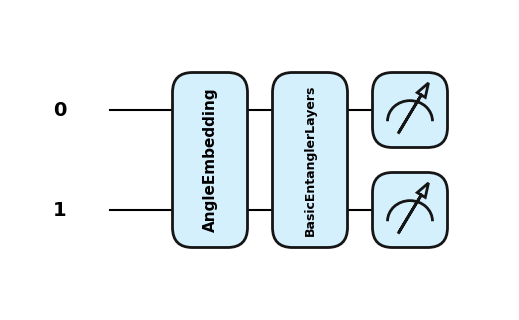

In [17]:

# --- QUANTUM INSPECTION UTILITIES ---
if USE_QUANTUM:
    try:
        from quantum_weights import (
            summarize_quantum_weights,
            find_classical_to_quantum_mapper,
            draw_quantum_circuit_from_model
        )
        import json

        # Print summarized parameter metadata mapping the active quantum module footprint
        print("--- Model Quantum Weights Summary ---")
        print(json.dumps(summarize_quantum_weights(best_model), indent=2))

        # Identify the classical transition gateway boundary feeding the QNode
        print("\n--- Classical-to-Quantum Projection Layer ---")
        print(find_classical_to_quantum_mapper(best_model))

        # Structurally dissect and draw the underlying quantum topography
        print("\n--- Quantum Circuit Topology Reconstructed ---")
        # This purely outlines structure, relying on a generalized dummy scalar representation
        draw_quantum_circuit_from_model(best_model, style="pennylane")

    except Exception as exc:
        print(f"Quantum structural recap failed: {exc}")
else:
    print("Quantum structural recap skipped (USE_QUANTUM=False or omitted).")

In [18]:
# --- PERSIST QUANTUM VERIFICATION BUNDLE (HYBRIDS ONLY) ---
#
# This cell exports everything needed for hardware_verification.ipynb to
# perform complete, reproducible hybrid inference without requiring the
# training session to be alive.
#
# Subset selection is done HERE so both simulator and hardware runs always
# evaluate the exact same samples.
if USE_QUANTUM:
    try:
        import os
        import json
        import numpy as np
        import torch
        from pathlib import Path
        from collections import defaultdict

        from src.quantum_weights import (
            extract_quantum_weights,
            summarize_quantum_weights,
            find_classical_to_quantum_mapper,
            find_final_classifier,
            infer_quantum_metadata,
            find_quantum_layer,
        )

        export_dir = Path(config["model_dir"]) / "quantum_artifacts"
        export_dir.mkdir(parents=True, exist_ok=True)

        print(f"Saving verification bundle to: {export_dir}")
        print(f"  N_VERIFICATION_SAMPLES = {N_VERIFICATION_SAMPLES}")

        # ── 1. Quantum weights ───────────────────────────────────────────────
        quantum_weights = extract_quantum_weights(best_model)
        torch.save(quantum_weights, export_dir / "quantum_weights.pt")
        np.savez(
            export_dir / "quantum_weights.npz",
            **{k: v.detach().cpu().numpy() for k, v in quantum_weights.items()}
        )
        print("Saved quantum_weights.{pt,npz}")

        # ── 2. Quantum weights summary ───────────────────────────────────────
        quantum_summary = summarize_quantum_weights(best_model)
        with open(export_dir / "quantum_weights_summary.json", "w") as f:
            json.dump(quantum_summary, f, indent=2)

        # ── 3. Quantum metadata ──────────────────────────────────────────────
        try:
            quantum_metadata = infer_quantum_metadata(best_model)
        except Exception as exc:
            quantum_metadata = {"error": str(exc)}
        with open(export_dir / "quantum_metadata.json", "w") as f:
            json.dump(quantum_metadata, f, indent=2)
        print(f"Saved quantum_metadata.json: n_qubits={quantum_metadata.get('n_qubits')}, q_depth={quantum_metadata.get('q_depth')}")

        # ── 4. Classical → quantum mapper ────────────────────────────────────
        mapper = find_classical_to_quantum_mapper(best_model)
        if mapper is not None:
            torch.save(mapper.state_dict(), export_dir / "classical_to_quantum_mapper.pt")
            with open(export_dir / "classical_to_quantum_mapper_summary.json", "w") as f:
                json.dump({
                    "class_name": mapper.__class__.__name__,
                    "in_features": int(mapper.in_features) if hasattr(mapper, "in_features") else None,
                    "out_features": int(mapper.out_features) if hasattr(mapper, "out_features") else None,
                    "has_bias": mapper.bias is not None if hasattr(mapper, "bias") else False,
                }, f, indent=2)

        # ── 5. Final classifier weights & bias ───────────────────────────────
        final_clf = find_final_classifier(best_model)
        if final_clf is not None:
            clf_weight = final_clf.weight.detach().cpu().numpy()   # (n_classes, n_qubits)
            clf_bias   = final_clf.bias.detach().cpu().numpy()     # (n_classes,)
            np.save(export_dir / "classifier_weight.npy", clf_weight)
            np.save(export_dir / "classifier_bias.npy",   clf_bias)
            print(f"Saved classifier_weight {clf_weight.shape} and classifier_bias {clf_bias.shape}")
        else:
            print("WARNING: Final classifier layer not found.")

        # ── 6. Class-name mapping ────────────────────────────────────────────
        with open(export_dir / "class_names.json", "w") as f:
            json.dump(class_names, f, indent=2)
        num_classes = len(class_names)
        print(f"Saved class_names: {class_names}")

        # ── 7. Balanced verification subset ─────────────────────────────────
        # Build a reproducible, class-balanced subset from the validation split.
        # We collect ceil(N_VERIFICATION_SAMPLES / num_classes) samples per class,
        # then trim to exactly N_VERIFICATION_SAMPLES.
        qlayer = find_quantum_layer(best_model)
        if qlayer is None or "val" not in dataloaders or dataloaders["val"] is None:
            raise RuntimeError("Validation dataloader or quantum layer not available.")

        samples_per_class = max(1, -(-N_VERIFICATION_SAMPLES // num_classes))  # ceiling div
        class_buckets = defaultdict(list)   # label -> list of (x_tensor, int_label)

        for x_batch, y_batch in dataloaders["val"]:
            for x, y in zip(x_batch, y_batch):
                lbl = int(y.item())
                if len(class_buckets[lbl]) < samples_per_class:
                    class_buckets[lbl].append((x, lbl))
            # Stop early when all classes are filled
            if all(len(class_buckets[c]) >= samples_per_class for c in range(num_classes)):
                break

        # Flatten into a deterministic order: class 0, class 1, ...
        flat_samples = []
        for c in range(num_classes):
            flat_samples.extend(class_buckets[c])
        flat_samples = flat_samples[:N_VERIFICATION_SAMPLES]   # exact trim

        subset_x      = torch.stack([s[0] for s in flat_samples])  # (N, ...)
        subset_labels = torch.tensor([s[1] for s in flat_samples]) # (N,)
        subset_N      = len(flat_samples)

        print(f"\nVerification subset: {subset_N} samples")
        for c in range(num_classes):
            cnt = sum(1 for s in flat_samples if s[1] == c)
            print(f"  class {c} ({class_names[c]}): {cnt} sample(s)")

        # ── 8. Capture quantum-layer inputs + reference outputs ──────────────
        captured_q_inputs = []

        def _hook(module, args):
            if args and args[0] is not None:
                captured_q_inputs.append(args[0].detach().cpu())

        hook_handle = qlayer.register_forward_pre_hook(_hook)
        best_model.eval()
        with torch.no_grad():
            subset_x_dev  = subset_x.to(device)
            ref_logits    = best_model(subset_x_dev)    # PL reference logits
        hook_handle.remove()

        # ── 9. Save all subset artifacts ─────────────────────────────────────
        true_labels_np = subset_labels.numpy()
        np.save(export_dir / "true_labels.npy", true_labels_np)
        label_names = [class_names[l] for l in true_labels_np]
        print(f"\nTrue labels : {label_names}")

        ref_logits_np = ref_logits.detach().cpu().numpy()
        ref_preds_np  = ref_logits_np.argmax(axis=1)
        np.save(export_dir / "reference_logits.npy", ref_logits_np)
        np.save(export_dir / "reference_preds.npy",  ref_preds_np)
        ref_pred_names = [class_names[p] for p in ref_preds_np]
        print(f"PL ref preds: {ref_pred_names}")
        ref_acc = (ref_preds_np == true_labels_np).mean() * 100
        print(f"PL reference accuracy on subset: {ref_acc:.1f}%")

        # Quantum-layer inputs (captured from forward pass)
        if captured_q_inputs:
            q_inputs = torch.cat(captured_q_inputs, dim=0)[:subset_N]
            np.save(export_dir / "quantum_inputs.npy", q_inputs.numpy())
            with open(export_dir / "quantum_inputs_summary.json", "w") as f:
                summary_dict = {
                    "shape": list(q_inputs.shape),
                    "dtype": str(q_inputs.dtype),
                    "min": float(q_inputs.min()),
                    "max": float(q_inputs.max()),
                    "mean": float(q_inputs.mean()),
                }
                json.dump(summary_dict, f, indent=2)
            print(f"Saved quantum_inputs.npy: shape={tuple(q_inputs.shape)}")
        else:
            print("WARNING: Quantum inputs could not be captured.")

        # Sample index identifiers
        sample_ids = list(range(subset_N))
        with open(export_dir / "sample_ids.json", "w") as f:
            json.dump(sample_ids, f)

        # Bundle manifest
        manifest = {
            "n_verification_samples": subset_N,
            "num_classes": num_classes,
            "class_names": class_names,
            "n_qubits": quantum_metadata.get("n_qubits"),
            "q_depth": quantum_metadata.get("q_depth"),
            "pl_reference_accuracy_pct": round(float(ref_acc), 2),
        }
        with open(export_dir / "bundle_manifest.json", "w") as f:
            json.dump(manifest, f, indent=2)

        print("\nVerification bundle manifest:")
        print(json.dumps(manifest, indent=2))

        print("\nAll saved files:")
        for fn in sorted(os.listdir(export_dir)):
            print(f"  {fn}")

    except Exception as exc:
        import traceback
        print(f"Export failed: {exc}")
        traceback.print_exc()
else:
    print("USE_QUANTUM=False — verification bundle export skipped.")


Saving verification bundle to: /content/drive/MyDrive/CREMAD/Models/emb_resnet18/emb_resnet18_quantum/run_03-18_20-43-29/quantum_artifacts
  N_VERIFICATION_SAMPLES = 200
Saved quantum_weights.{pt,npz}
Saved quantum_metadata.json: n_qubits=2, q_depth=3
Saved classifier_weight (2, 2) and classifier_bias (2,)
Saved class_names: ['ANG', 'SAD']

Verification subset: 200 samples
  class 0 (ANG): 100 sample(s)
  class 1 (SAD): 100 sample(s)

True labels : ['ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 'ANG', 